# HyperVerge DL Assignment 2025 — ResNet-18 pipeline

**Task:** 10-class animal classifier (class names are Italian: `cane`, `cavallo`, `elefante`, …).
**Phase 1:** labeled data only (779 images). **Phase 2:** labeled + 14,800 unlabeled.
**Architecture:** ResNet-18 only (ImageNet-pretrained weights are allowed).

### What the data looks like (from the EDA)
| Split | Count | Color | Orientation |
|---|---|---|---|
| labeled | 779 | **all grayscale** | upright |
| unlabeled | 14,800 | mostly **RGB** | **vertically flipped** (top↔bottom; a watermark reads correctly after `FLIP_TOP_BOTTOM`, not after a 180° rotation) |
| test | ? | checked automatically | checked automatically (see `detect_vflip`) |

Class counts are skewed (145 `cane` vs 43 `elefante`, 3.4:1), and grading uses per-class accuracy, so every model is selected on **balanced (macro) accuracy**.

### Design decisions (Phase 1)
1. **Canonicalize the domain:** every image goes to grayscale (replicated to 3 channels for the pretrained stem) and is flipped upright when needed. The train, val, test and unlabeled images then all come from the same input distribution.
2. **More samples:** 779 images is tiny. Each image is seen `repeats`× per epoch, each time with a fresh random augmentation (crop, horizontal/vertical flip, rotation, brightness/contrast, blur, erasing). On top of that, **MixUp/CutMix** creates new convex combinations. Augmenting on the fly beats writing augmented copies to disk, because the model never sees the exact same sample twice.
3. **Loss:** cross-entropy with **label smoothing 0.1** and **inverse-frequency class weights**, with soft-target mixing. The alternative is `loss_mode='logit_adjust'`: plain CE during training, then `logits -= τ·log(prior)` at inference, with τ tuned on val.
4. **Optimization:** AdamW with a lower LR on the backbone (1e-4) than on the head (1e-3), plus cosine schedule with warmup, AMP, and an **EMA of the weights** that is used for evaluation.
5. **Evaluation:** stratified 80/20 split, macro accuracy and per-class accuracy, confusion matrix. **TTA** (center crop and full image, each with a horizontal flip) at inference.
6. **Final model:** after picking settings on val, optionally retrain on 100% of the labeled data with the same schedule.

## 0. Setup
Run from the repo root with the `.venv` Python kernel. Labeled data is read from `HV-AI-2025/` (override with env `HV_DATA_ROOT`) and outputs go to `outputs/` (`HV_OUT_DIR`). For test inference, put the test images in a folder whose name contains `test` (e.g. `test_data/`), or set `CFG.test_dir`.

## 1. Imports, config, reproducibility

In [1]:
import os, glob, math, copy, time, random
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE, '| torch', torch.__version__)

device: cuda | torch 2.6.0+cu124


In [2]:
@dataclass
class Config:
    # paths
    data_root: str = os.environ.get('HV_DATA_ROOT', 'HV-AI-2025')   # relative to the repo root
    test_dir: str = ''                 # '' -> auto-discover (see find_test_dir)
    out_dir: str = os.environ.get('HV_OUT_DIR', 'outputs')
    # data
    img_size: int = 224
    cache_short_side: int = 256        # images are decoded once and cached at this short side
    val_frac: float = 0.2
    repeats: int = 3                   # fresh augmentations of each image per epoch ("more samples")
    vflip_p: float = 0.2               # vertical-flip augmentation (robustness to unknown test orientation)
    rot_deg: float = 20.0
    # training
    epochs: int = 40
    warmup_epochs: int = 2
    batch_size: int = 64
    lr_backbone: float = 1e-4
    lr_head: float = 1e-3
    weight_decay: float = 0.05
    dropout: float = 0.2
    label_smoothing: float = 0.1
    loss_mode: str = 'weighted'        # 'weighted' (class-weighted CE) | 'logit_adjust' (plain CE + post-hoc τ·log prior)
    weight_scheme: str = 'inv_freq'    # 'inv_freq' | 'effective' (Cui et al., beta=0.999)
    mix_prob: float = 0.5              # probability a batch is mixed (MixUp or CutMix, 50/50)
    mixup_alpha: float = 0.2
    cutmix_alpha: float = 1.0
    ema_decay: float = 0.995
    amp: bool = True
    num_workers: int = 8                # Linux; set 0 on Windows (notebook-defined classes can't be pickled to workers)
    seed: int = 42
    retrain_full: bool = True          # final Phase 1 model trained on 100% of labeled data

CFG = Config()
os.makedirs(CFG.out_dir, exist_ok=True)

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything(CFG.seed)
asdict(CFG)

{'data_root': 'HV-AI-2025',
 'test_dir': '',
 'out_dir': 'outputs',
 'img_size': 224,
 'cache_short_side': 256,
 'val_frac': 0.2,
 'repeats': 3,
 'vflip_p': 0.2,
 'rot_deg': 20.0,
 'epochs': 40,
 'warmup_epochs': 2,
 'batch_size': 64,
 'lr_backbone': 0.0001,
 'lr_head': 0.001,
 'weight_decay': 0.05,
 'dropout': 0.2,
 'label_smoothing': 0.1,
 'loss_mode': 'weighted',
 'weight_scheme': 'inv_freq',
 'mix_prob': 0.5,
 'mixup_alpha': 0.2,
 'cutmix_alpha': 1.0,
 'ema_decay': 0.995,
 'amp': True,
 'num_workers': 8,
 'seed': 42,
 'retrain_full': True}

## 2. Data loading & canonicalization
`load_image` converts to grayscale (`L`), optionally undoes the vertical flip, and downsizes big originals (some are 4272 px wide) once so they can be cached in RAM.

In [3]:
IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

def load_image(path, vflip=False, short_side=CFG.cache_short_side):
    """Open an image as canonical grayscale, upright, with the short side capped at `short_side`."""
    img = Image.open(path)
    img = img.convert('L')                      # standardize color -> grayscale (labeled set is 100% grayscale)
    if vflip:
        img = img.transpose(Image.FLIP_TOP_BOTTOM)
    w, h = img.size
    s = short_side / min(w, h)
    if s < 1:
        img = img.resize((max(1, round(w * s)), max(1, round(h * s))), Image.BICUBIC)
    return img

def list_images(folder):
    return sorted(f for f in os.listdir(folder) if f.lower().endswith(IMG_EXTS))

def load_folder(folder, names, vflip=False):
    return [load_image(os.path.join(folder, n), vflip=vflip) for n in names]

In [4]:
LABELED_DIR = os.path.join(CFG.data_root, 'labeled_data')
labels_df = pd.read_csv(os.path.join(LABELED_DIR, 'labeled_data.csv'))   # columns: img_name, label

CLASSES = sorted(labels_df['label'].unique())
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)
labels_df['y'] = labels_df['label'].map(CLASS_TO_IDX)

t0 = time.time()
labeled_images = load_folder(os.path.join(LABELED_DIR, 'images'), labels_df['img_name'])
labeled_y = labels_df['y'].to_numpy()
print(f'loaded {len(labeled_images)} labeled images in {time.time()-t0:.1f}s')

class_counts = np.bincount(labeled_y, minlength=NUM_CLASSES)
pd.DataFrame({'class': CLASSES, 'count': class_counts}).set_index('class').T

loaded 779 labeled images in 1.9s


class,cane,cavallo,elefante,farfalla,gallina,gatto,mucca,pecora,ragno,scoiattolo
count,145,78,43,63,92,50,55,54,144,55


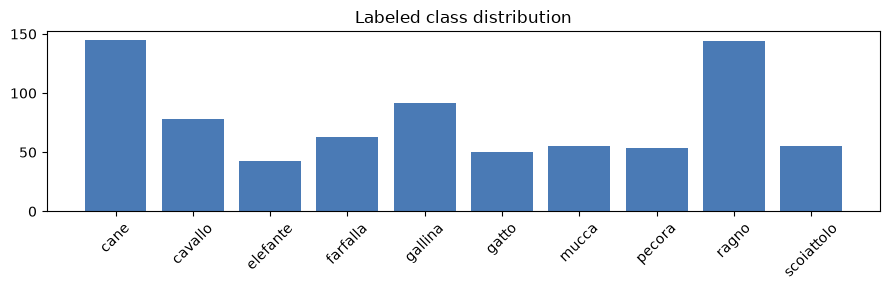

In [5]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(CLASSES, class_counts, color='#4a7ab5')
ax.set_title('Labeled class distribution'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

### Stratified train / val split

In [6]:
idx_all = np.arange(len(labeled_images))
idx_tr, idx_val = train_test_split(idx_all, test_size=CFG.val_frac, stratify=labeled_y, random_state=CFG.seed)
print('train', len(idx_tr), '| val', len(idx_val))
print('val per class:', np.bincount(labeled_y[idx_val], minlength=NUM_CLASSES))

train 623 | val 156
val per class: [29 16  8 13 18 10 11 11 29 11]


## 3. Augmentations
- `train`: the Phase 1 recipe. Random resized crop, horizontal flip, occasional vertical flip, rotation, brightness/contrast jitter, blur, random erasing.
- `weak` / `strong`: the pair Phase 2 (FixMatch) will use. They're defined here so both phases share one module.
- `eval_views`: TTA views (center crop and full image, each also horizontally flipped).

Inputs are single-channel `L` images. `Grayscale(3)` replicates the channel so the pretrained RGB stem works unchanged, and ImageNet stats are kept for normalization.

In [7]:
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

def to_tensor_3ch():
    return [T.Grayscale(num_output_channels=3), T.ToTensor(), T.Normalize(MEAN, STD)]

def build_transforms(cfg):
    size = cfg.img_size
    train = T.Compose([
        T.RandomResizedCrop(size, scale=(0.35, 1.0), ratio=(0.75, 1.33)),
        T.RandomHorizontalFlip(),
        T.RandomVerticalFlip(p=cfg.vflip_p),
        T.RandomApply([T.RandomRotation(cfg.rot_deg, fill=0)], p=0.5),
        T.RandomApply([T.ColorJitter(brightness=0.4, contrast=0.4)], p=0.8),
        T.RandomApply([T.GaussianBlur(5, sigma=(0.1, 2.0))], p=0.2),
        T.RandomAutocontrast(p=0.2),
        *to_tensor_3ch(),
        T.RandomErasing(p=0.25, scale=(0.02, 0.2)),
    ])
    weak = T.Compose([
        T.RandomResizedCrop(size, scale=(0.6, 1.0)),
        T.RandomHorizontalFlip(),
        *to_tensor_3ch(),
    ])
    strong = T.Compose([
        T.RandomResizedCrop(size, scale=(0.35, 1.0)),
        T.RandomHorizontalFlip(),
        T.RandAugment(num_ops=2, magnitude=10),
        *to_tensor_3ch(),
        T.RandomErasing(p=0.5, scale=(0.02, 0.25)),
    ])
    center = [T.Resize(size), T.CenterCrop(size)]
    full = [T.Resize((size, size))]
    eval_views = {
        'center':       T.Compose(center + to_tensor_3ch()),
        'center_hflip': T.Compose(center + [T.RandomHorizontalFlip(p=1.0)] + to_tensor_3ch()),
        'full':         T.Compose(full + to_tensor_3ch()),
        'full_hflip':   T.Compose(full + [T.RandomHorizontalFlip(p=1.0)] + to_tensor_3ch()),
    }
    return {'train': train, 'weak': weak, 'strong': strong, 'eval': eval_views['center'], 'eval_views': eval_views}

TFMS = build_transforms(CFG)

In [8]:
class ImageDataset(Dataset):
    """In-memory PIL images; `repeats` makes one epoch show each image several times with fresh augmentations.
    Unlabeled samples get label -1 so labeled/unlabeled batches share one collate path."""
    def __init__(self, images, labels=None, transform=None, repeats=1):
        self.images, self.labels, self.transform, self.repeats = images, labels, transform, repeats

    def __len__(self):
        return len(self.images) * self.repeats

    def __getitem__(self, i):
        i %= len(self.images)
        x = self.transform(self.images[i])
        y = -1 if self.labels is None else int(self.labels[i])
        return x, y

def subset(seq, idx):
    return [seq[i] for i in idx]

def make_loader(images, labels, transform, cfg, train, repeats=1):
    ds = ImageDataset(images, labels, transform, repeats=repeats)
    return DataLoader(ds, batch_size=cfg.batch_size, shuffle=train, drop_last=train,
                      num_workers=cfg.num_workers, pin_memory=DEVICE.type == 'cuda',
                      persistent_workers=cfg.num_workers > 0)

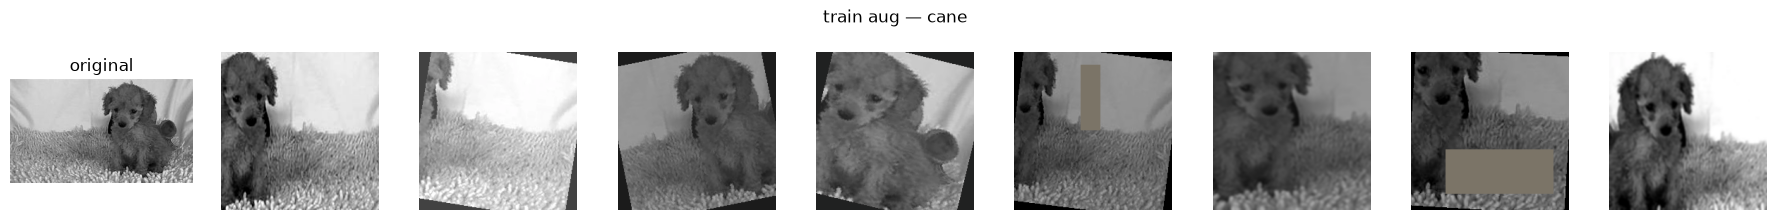

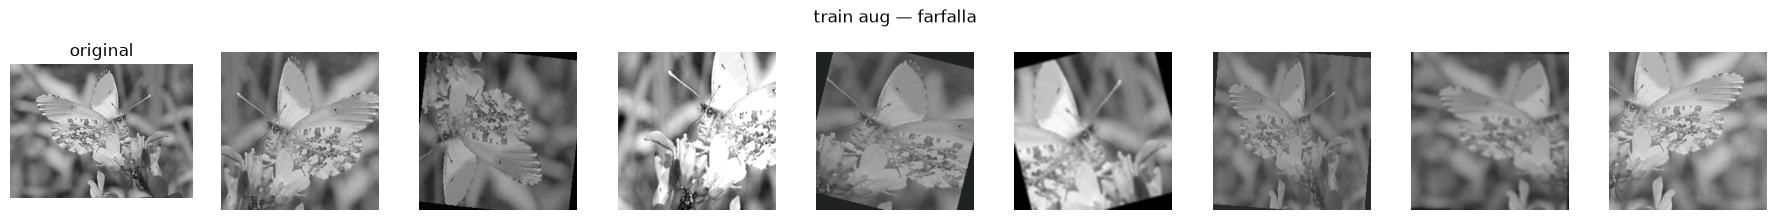

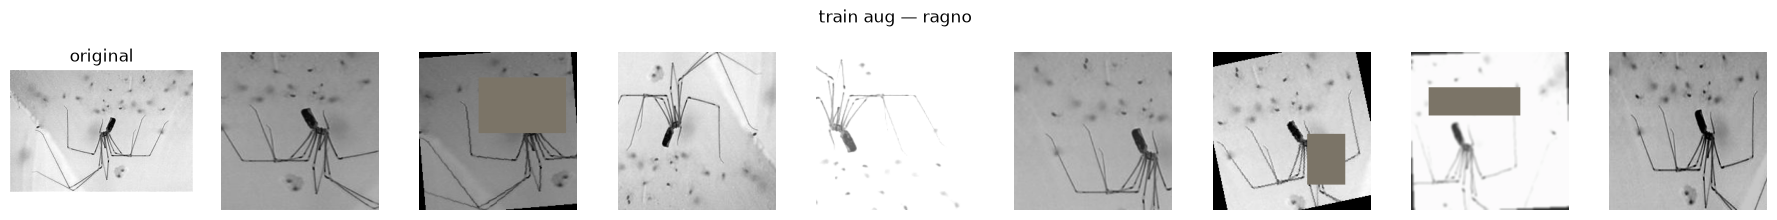

In [9]:
def denorm(x):
    return (x * torch.tensor(STD)[:, None, None] + torch.tensor(MEAN)[:, None, None]).clamp(0, 1)

def show_augmentations(img, tfm, n=8, title=''):
    fig, axes = plt.subplots(1, n + 1, figsize=(2 * (n + 1), 2.2))
    axes[0].imshow(img, cmap='gray'); axes[0].set_title('original')
    for ax in axes[1:]:
        ax.imshow(denorm(tfm(img)).permute(1, 2, 0))
    for ax in axes: ax.axis('off')
    fig.suptitle(title); plt.tight_layout(); plt.show()

for k in [0, 300, 600]:
    show_augmentations(labeled_images[k], TFMS['train'], title=f'train aug — {labels_df.label[k]}')

## 4. Model, loss, EMA, schedule

In [10]:
def build_model(num_classes=NUM_CLASSES, dropout=CFG.dropout, pretrained=True):
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)
    model.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(model.fc.in_features, num_classes))
    return model

def param_groups(model, cfg):
    head = list(model.fc.parameters())
    head_ids = {id(p) for p in head}
    backbone = [p for p in model.parameters() if id(p) not in head_ids]
    return [{'params': backbone, 'lr': cfg.lr_backbone}, {'params': head, 'lr': cfg.lr_head}]

def class_weights(counts, scheme='inv_freq', beta=0.999):
    counts = torch.as_tensor(counts, dtype=torch.float)
    if scheme == 'inv_freq':
        w = 1.0 / counts
    elif scheme == 'effective':                      # Cui et al. 2019, class-balanced loss
        w = (1 - beta) / (1 - beta ** counts)
    else:
        w = torch.ones_like(counts)
    return w / w.mean()

def build_criterion(cfg, counts):
    weight = class_weights(counts, cfg.weight_scheme) if cfg.loss_mode == 'weighted' else None
    # logit_adjust -> plain (unweighted) CE; the prior correction happens at inference only
    return nn.CrossEntropyLoss(weight=None if weight is None else weight.to(DEVICE),
                               label_smoothing=cfg.label_smoothing)

In [11]:
def mix_batch(x, y, cfg):
    """MixUp or CutMix (50/50) with probability cfg.mix_prob. Returns x, y_a, y_b, lam;
    loss = lam*CE(y_a) + (1-lam)*CE(y_b), exact because CE is linear in the target."""
    if random.random() >= cfg.mix_prob:
        return x, y, y, 1.0
    perm = torch.randperm(x.size(0), device=x.device)
    if random.random() < 0.5:
        lam = float(np.random.beta(cfg.mixup_alpha, cfg.mixup_alpha))
        x = lam * x + (1 - lam) * x[perm]
    else:
        lam = float(np.random.beta(cfg.cutmix_alpha, cfg.cutmix_alpha))
        H, W = x.shape[2:]
        rh, rw = int(H * math.sqrt(1 - lam)), int(W * math.sqrt(1 - lam))
        cy, cx = np.random.randint(H), np.random.randint(W)
        y1, y2 = max(cy - rh // 2, 0), min(cy + rh // 2, H)
        x1, x2 = max(cx - rw // 2, 0), min(cx + rw // 2, W)
        x = x.clone()
        x[:, :, y1:y2, x1:x2] = x[perm, :, y1:y2, x1:x2]
        lam = 1 - (y2 - y1) * (x2 - x1) / (H * W)       # correct lam for the clipped box
    return x, y, y[perm], lam

class ModelEMA:
    """Exponential moving average of weights (BN buffers included); used for evaluation and pseudo-labeling."""
    def __init__(self, model, decay):
        self.ema = copy.deepcopy(model).eval()
        for p in self.ema.parameters():
            p.requires_grad_(False)
        self.decay, self.updates = decay, 0

    @torch.no_grad()
    def update(self, model):
        self.updates += 1
        d = min(self.decay, (1 + self.updates) / (10 + self.updates))   # warm up the average early on
        msd = model.state_dict()
        for k, v in self.ema.state_dict().items():
            if v.dtype.is_floating_point:
                v.mul_(d).add_(msd[k].detach(), alpha=1 - d)
            else:
                v.copy_(msd[k])

def warmup_cosine(optimizer, warmup_steps, total_steps):
    def f(step):
        if step < warmup_steps:
            return (step + 1) / warmup_steps
        t = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * t))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, f)

## 5. Train / evaluate

In [12]:
@torch.no_grad()
def predict_logits(model, images, transform, cfg):
    model.eval()
    loader = make_loader(images, None, transform, cfg, train=False)
    out = []
    for x, _ in loader:
        with torch.autocast(DEVICE.type, enabled=cfg.amp and DEVICE.type == 'cuda'):
            out.append(model(x.to(DEVICE, non_blocking=True)).float().cpu())
    return torch.cat(out)

def predict_tta(model, images, cfg, views=('center', 'center_hflip', 'full', 'full_hflip')):
    """Average softmax over TTA views; returns log-probs so logit adjustment still applies."""
    probs = torch.stack([predict_logits(model, images, TFMS['eval_views'][v], cfg).softmax(1) for v in views]).mean(0)
    return probs.clamp_min(1e-8).log()

def adjust_logits(logits, prior, tau):
    return logits - tau * torch.log(torch.as_tensor(prior, dtype=torch.float)) if tau else logits

def compute_metrics(logits, y):
    pred = logits.argmax(1).numpy(); y = np.asarray(y)
    per_class = np.array([(pred[y == c] == c).mean() if (y == c).any() else np.nan for c in range(NUM_CLASSES)])
    return {'acc': float((pred == y).mean()), 'macro_acc': float(np.nanmean(per_class)), 'per_class': per_class}

def tune_tau(logits, y, prior, grid=np.linspace(0, 2, 21)):
    scores = [(compute_metrics(adjust_logits(logits, prior, t), y)['macro_acc'], t) for t in grid]
    best = max(scores)
    return best[1], best[0]

In [13]:
def train_one_epoch(model, ema, loader, criterion, optimizer, scheduler, scaler, cfg):
    model.train()
    total, n = 0.0, 0
    for x, y in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        x, ya, yb, lam = mix_batch(x, y, cfg)
        with torch.autocast(DEVICE.type, enabled=cfg.amp and DEVICE.type == 'cuda'):
            logits = model(x)
            loss = lam * criterion(logits, ya) + (1 - lam) * criterion(logits, yb)
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update(); scheduler.step()
        ema.update(model)
        total += loss.item() * x.size(0); n += x.size(0)
    return total / n

def fit(train_imgs, train_y, cfg, val_imgs=None, val_y=None, tag='run'):
    """Train ResNet-18 on (train_imgs, train_y). If val data is given, track EMA macro-acc each epoch
    and keep the best EMA weights; otherwise keep the final EMA weights."""
    seed_everything(cfg.seed)
    model = build_model().to(DEVICE)
    criterion = build_criterion(cfg, np.bincount(train_y, minlength=NUM_CLASSES))
    optimizer = torch.optim.AdamW(param_groups(model, cfg), weight_decay=cfg.weight_decay)
    loader = make_loader(train_imgs, train_y, TFMS['train'], cfg, train=True, repeats=cfg.repeats)
    steps = cfg.epochs * len(loader)
    scheduler = warmup_cosine(optimizer, cfg.warmup_epochs * len(loader), steps)
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=cfg.amp and DEVICE.type == 'cuda')
    ema = ModelEMA(model, cfg.ema_decay)

    history, best = [], (-1.0, None, -1)
    for epoch in range(1, cfg.epochs + 1):
        t0 = time.time()
        loss = train_one_epoch(model, ema, loader, criterion, optimizer, scheduler, scaler, cfg)
        row = {'epoch': epoch, 'loss': loss}
        if val_imgs is not None:
            m = compute_metrics(predict_logits(ema.ema, val_imgs, TFMS['eval'], cfg), val_y)
            row.update(val_acc=m['acc'], val_macro=m['macro_acc'])
            if m['macro_acc'] > best[0]:
                best = (m['macro_acc'], copy.deepcopy(ema.ema.state_dict()), epoch)
        history.append(row)
        print(f"[{tag}] ep {epoch:3d}/{cfg.epochs} loss {loss:.4f}"
              + (f" | val acc {row['val_acc']:.4f} macro {row['val_macro']:.4f}" if val_imgs is not None else '')
              + f" | {time.time()-t0:.1f}s")

    final = ema.ema
    if best[1] is not None:
        final.load_state_dict(best[1])
        print(f'[{tag}] best EMA macro-acc {best[0]:.4f} @ epoch {best[2]}')
    return final, pd.DataFrame(history)

In [14]:
def plot_history(hist, title=''):
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
    ax[0].plot(hist.epoch, hist.loss); ax[0].set_title('train loss')
    if 'val_macro' in hist:
        ax[1].plot(hist.epoch, hist.val_acc, label='acc'); ax[1].plot(hist.epoch, hist.val_macro, label='macro acc')
        ax[1].legend(); ax[1].set_title('val (EMA)')
    fig.suptitle(title); plt.tight_layout(); plt.show()

def report(logits, y, title=''):
    m = compute_metrics(logits, y)
    print(f"{title} acc {m['acc']:.4f} | macro acc {m['macro_acc']:.4f}")
    print(pd.Series(m['per_class'], index=CLASSES).round(3).to_string())
    cm = confusion_matrix(y, logits.argmax(1).numpy(), labels=range(NUM_CLASSES))
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(NUM_CLASSES), CLASSES, rotation=60); ax.set_yticks(range(NUM_CLASSES), CLASSES)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=8, color='white' if cm[i, j] > cm.max() / 2 else 'black')
    ax.set_xlabel('pred'); ax.set_ylabel('true'); ax.set_title(title); plt.tight_layout(); plt.show()
    return m

## 6. Phase 1 — train with validation
⚠️ **Training starts here.** Everything above only defines code and loads data.

[p1-val] ep   1/40 loss 2.2227 | val acc 0.5897 macro 0.5971 | 3.0s
[p1-val] ep   2/40 loss 1.5808 | val acc 0.8333 macro 0.8285 | 1.4s
[p1-val] ep   3/40 loss 1.3428 | val acc 0.8654 macro 0.8542 | 1.4s
[p1-val] ep   4/40 loss 1.1384 | val acc 0.8718 macro 0.8642 | 1.3s
[p1-val] ep   5/40 loss 1.0759 | val acc 0.8782 macro 0.8676 | 1.3s
[p1-val] ep   6/40 loss 1.0349 | val acc 0.8526 macro 0.8373 | 1.3s
[p1-val] ep   7/40 loss 1.0624 | val acc 0.8526 macro 0.8404 | 1.3s
[p1-val] ep   8/40 loss 1.0690 | val acc 0.8846 macro 0.8710 | 1.3s
[p1-val] ep   9/40 loss 1.0928 | val acc 0.8846 macro 0.8654 | 1.3s
[p1-val] ep  10/40 loss 0.9646 | val acc 0.8782 macro 0.8598 | 1.3s
[p1-val] ep  11/40 loss 0.8228 | val acc 0.8718 macro 0.8536 | 1.3s
[p1-val] ep  12/40 loss 1.0366 | val acc 0.8782 macro 0.8563 | 1.3s
[p1-val] ep  13/40 loss 1.0916 | val acc 0.8654 macro 0.8457 | 1.3s
[p1-val] ep  14/40 loss 0.9535 | val acc 0.8782 macro 0.8610 | 1.3s
[p1-val] ep  15/40 loss 1.1639 | val acc 0.8782 

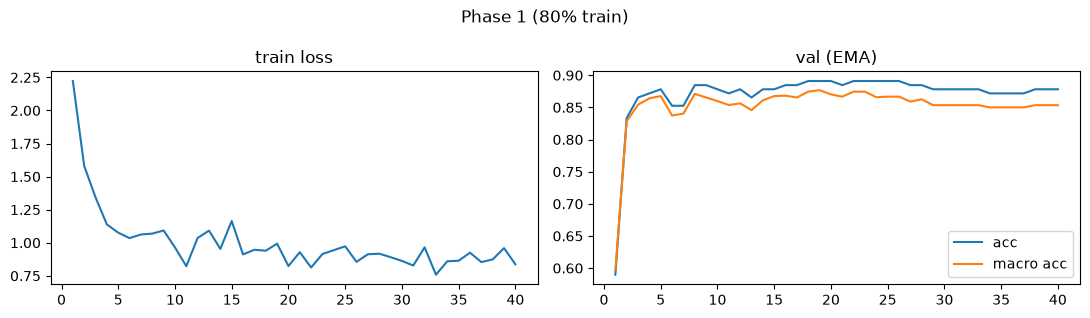

In [15]:
tr_imgs, tr_y = subset(labeled_images, idx_tr), labeled_y[idx_tr]
val_imgs, val_y = subset(labeled_images, idx_val), labeled_y[idx_val]

model_val, hist = fit(tr_imgs, tr_y, CFG, val_imgs, val_y, tag='p1-val')
plot_history(hist, 'Phase 1 (80% train)')

Phase 1 val (TTA) acc 0.8782 | macro acc 0.8655
cane          0.931
cavallo       0.938
elefante      1.000
farfalla      0.846
gallina       0.889
gatto         0.700
mucca         0.909
pecora        0.727
ragno         0.897
scoiattolo    0.818


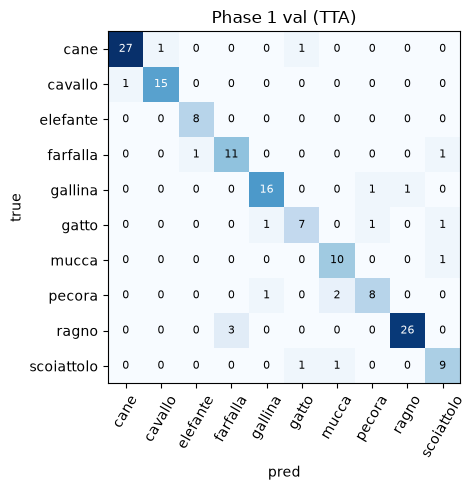

{'acc': 0.8782051282051282,
 'macro_acc': 0.8654674396484742,
 'per_class': array([0.93103448, 0.9375    , 1.        , 0.84615385, 0.88888889,
        0.7       , 0.90909091, 0.72727273, 0.89655172, 0.81818182])}

In [16]:
val_logits = predict_tta(model_val, val_imgs, CFG)
prior = np.bincount(tr_y, minlength=NUM_CLASSES) / len(tr_y)
TAU = 0.0
if CFG.loss_mode == 'logit_adjust':
    TAU, macro = tune_tau(val_logits, val_y, prior)
    print(f'tuned tau = {TAU:.2f} (val macro acc {macro:.4f})')
report(adjust_logits(val_logits, prior, TAU), val_y, 'Phase 1 val (TTA)')

## 7. Phase 1 — final model on 100% of the labeled data
Same config and epoch count as the validated run; the final EMA weights are used. Skip this (`retrain_full=False`) to use the val-selected model instead.

In [17]:
if CFG.retrain_full:
    model_p1, hist_full = fit(labeled_images, labeled_y, CFG, tag='p1-full')
else:
    model_p1 = model_val
torch.save({'state_dict': model_p1.state_dict(), 'classes': CLASSES, 'tau': TAU, 'cfg': asdict(CFG)},
           os.path.join(CFG.out_dir, 'phase1_resnet18.pt'))
print('saved', os.path.join(CFG.out_dir, 'phase1_resnet18.pt'))

[p1-full] ep   1/40 loss 2.2224 | 1.4s
[p1-full] ep   2/40 loss 1.4875 | 0.9s
[p1-full] ep   3/40 loss 1.2834 | 0.8s
[p1-full] ep   4/40 loss 1.1826 | 0.9s
[p1-full] ep   5/40 loss 1.0748 | 0.9s
[p1-full] ep   6/40 loss 1.0930 | 1.1s
[p1-full] ep   7/40 loss 1.1734 | 0.9s
[p1-full] ep   8/40 loss 1.0016 | 0.9s
[p1-full] ep   9/40 loss 0.8885 | 0.9s
[p1-full] ep  10/40 loss 1.0500 | 0.9s
[p1-full] ep  11/40 loss 1.0612 | 1.0s
[p1-full] ep  12/40 loss 1.1603 | 1.0s
[p1-full] ep  13/40 loss 0.9836 | 0.9s
[p1-full] ep  14/40 loss 1.0019 | 1.0s
[p1-full] ep  15/40 loss 0.9419 | 1.0s
[p1-full] ep  16/40 loss 0.9089 | 1.0s
[p1-full] ep  17/40 loss 0.9467 | 0.9s
[p1-full] ep  18/40 loss 0.8344 | 1.1s
[p1-full] ep  19/40 loss 0.9702 | 0.9s
[p1-full] ep  20/40 loss 0.9635 | 0.9s
[p1-full] ep  21/40 loss 0.8906 | 0.9s
[p1-full] ep  22/40 loss 0.9637 | 0.9s
[p1-full] ep  23/40 loss 0.9484 | 0.9s
[p1-full] ep  24/40 loss 0.8341 | 0.9s
[p1-full] ep  25/40 loss 0.8818 | 0.9s
[p1-full] ep  26/40 loss 

## 8. Test inference
The test set's orientation and color are unknown. `detect_vflip` checks which orientation the model is more confident on (mean max-softmax, as-is vs. flipped), so the same routine also verifies that the unlabeled set is flipped. Color is handled by the grayscale conversion in `load_image`.

### Test set preprocessing
The raw test set (`HV-AI-2025-Test/test_images`, 10,477 images) did not match the training domain, so it was preprocessed once, offline, before inference. The processed copy is in `test_images/`. Every image went through these steps, in order:

1. **Rotated 90° counter-clockwise (PIL `Image.ROTATE_90`).** The raw test images are sideways: the ground is on the left, and the median size is 225×300 (portrait) while the labeled images are 300×225 (landscape). A visual check of 18 random samples, including images with watermark text, showed that `ROTATE_90` makes all 18 upright. The training images are upright, so unrotated test images would come from a different input distribution. `detect_vflip` only tests top↔bottom flips and cannot catch a 90° rotation, which is why this was fixed up front.
2. **Converted to grayscale (`.convert('L')`).** 296 of 300 sampled test images are RGB, while all 779 labeled training images are grayscale. Converting removes color as a train/test difference.
3. **Resized so the short side is 256 px (bicubic, never upscaled).** This is exactly what `load_image` does (`cache_short_side=256`), so the model sees the same pixels. It also shrank the upload from 458 MB to 279 MB.
4. **Filenames and formats unchanged.** 9,662 `.jpeg`, 794 `.jpg` and 21 `.png`, all with their original names (JPEG re-saved at quality 95, PNG kept as PNG), because the submission's `path` column must match the original filenames exactly.

The test images are therefore loaded **as-is**, with no vertical flip and no `detect_vflip`.

In [18]:
def find_test_dir(cfg):
    if cfg.test_dir:
        return cfg.test_dir
    roots = [cfg.data_root, '.']
    cands = [d for r in roots for d in glob.glob(os.path.join(r, '**', '*test*'), recursive=True) if os.path.isdir(d)]
    cands += [os.path.join(d, 'images') for d in cands]
    cands = [d for d in dict.fromkeys(cands) if '.venv' not in d and 'site-packages' not in d
             and os.path.isdir(d) and list_images(d)]
    if not cands:
        raise FileNotFoundError('test images not found; set CFG.test_dir')
    return max(cands, key=lambda d: len(list_images(d)))

@torch.no_grad()
def detect_vflip(model, folder, names, cfg, n=300):
    """True if the (sampled) images look upside down to the model, i.e. flipped copies get higher confidence."""
    sample = random.Random(cfg.seed).sample(list(names), min(n, len(names)))
    conf = {}
    for flip in (False, True):
        imgs = load_folder(folder, sample, vflip=flip)
        conf[flip] = predict_logits(model, imgs, TFMS['eval'], cfg).softmax(1).max(1).values.mean().item()
    print(f'{folder}: mean confidence as-is {conf[False]:.3f} | flipped {conf[True]:.3f}')
    return conf[True] > conf[False]

def write_predictions(names, logits, path):
    df = pd.DataFrame({'path': names, 'predicted_label': [CLASSES[i] for i in logits.argmax(1).tolist()]})
    df.to_csv(path, index=False)
    print(f'wrote {len(df)} rows -> {path}')
    print(df.predicted_label.value_counts().to_string())
    return df

In [19]:
CFG.test_dir = 'test_images'   # preprocessed test set: already upright + grayscale (see above)
TEST_DIR = find_test_dir(CFG)
test_names = list_images(TEST_DIR)
test_vflip = False              # do not flip; detect_vflip is kept for the unlabeled set in Phase 2
test_images = load_folder(TEST_DIR, test_names, vflip=test_vflip)
print(f'{len(test_images)} test images from {TEST_DIR} (vflip={test_vflip})')

test_logits_p1 = adjust_logits(predict_tta(model_p1, test_images, CFG), prior, TAU)
torch.save(test_logits_p1, os.path.join(CFG.out_dir, 'phase1_test_logits.pt'))
p1_df = write_predictions(test_names, test_logits_p1, os.path.join(CFG.out_dir, 'phase1_predictions.csv'))
p1_df.head()

FileNotFoundError: test images not found; set CFG.test_dir

In [ ]:
# Sanity-check the submission file
sub = pd.read_csv(os.path.join(CFG.out_dir, 'phase1_predictions.csv'))
assert list(sub.columns) == ['path', 'predicted_label'], sub.columns
assert len(sub) == len(test_names) and set(sub.path) == set(test_names)
assert set(sub.predicted_label) <= set(CLASSES)
print(f'OK: {len(sub)} rows, header path,predicted_label, all labels in CLASSES')

## 9. Phase 2 — semi-supervised (next)
To come: the unlabeled set, flipped upright via `detect_vflip` and converted to grayscale, trained with FixMatch using per-class adaptive thresholds, initialized from `phase1_resnet18.pt`.

## Helper — evaluation server

In [ ]:
import requests

def send_results_for_evaluation(name, csv_file, email):
    url = "http://43.205.49.236:5050/inference"
    files = {'file': open(csv_file, 'rb')}
    data = {'email': email, 'name': name}
    response = requests.post(url, files=files, data=data)
    return response.json()

# print(send_results_for_evaluation('name', os.path.join(CFG.out_dir, 'phase1_predictions.csv'), 'your_email'))